# Performing Exploraratory Data Analysis on Sales data
---
- Target Variable: `Profit`
- Goal: To understand `Profit` w.r.t other variables

## Importing Modules

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## Loading the data

In [4]:
df = pd.read_csv("data/Superstore.csv", encoding = 'windows-1252')

In [5]:
pd.set_option("display.max_columns", None)

## Understanding the data

In [6]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [7]:
df.shape

(9994, 21)

In [8]:
print(f"Rows:     {df.shape[0]}")
print(f"Columns:  {df.shape[1]}")

Rows:     9994
Columns:  21


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Row ID,9994.0,4997.500000,2885.163629,1.000,2499.25000,4997.5000,7495.750,9994.000
Postal Code,9994.0,55190.379428,32063.693350,1040.000,23223.00000,56430.5000,90008.000,99301.000
Sales,9994.0,229.858001,623.245101,0.444,17.28000,54.4900,209.940,22638.480
Quantity,9994.0,3.789574,2.225110,1.000,2.00000,3.0000,5.000,14.000
Discount,9994.0,0.156203,0.206452,0.000,0.00000,0.2000,0.200,0.800
Profit,9994.0,28.656896,234.260108,-6599.978,1.72875,8.6665,29.364,8399.976


In [11]:
df.describe(include="object").T

C:\Users\L E N O V O\AppData\Local\Temp\ipykernel_3740\1274302342.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object").T


,count,unique,top,freq
Order ID,9994,5009,CA-2017-100111,14
Order Date,9994,1237,9/5/2016,38
Ship Date,9994,1334,12/16/2015,35
Ship Mode,9994,4,Standard Class,5968
Customer ID,9994,793,WB-21850,37
Customer Name,9994,793,William Brown,37
Segment,9994,3,Consumer,5191
Country,9994,1,United States,9994
City,9994,531,New York City,915
State,9994,49,California,2001


### Observations from this stage:
---

- There are no data missing, all values are non-null: from `df.info()`
- Numeric Columns are stored as str: Order ID, Customer ID, Product ID because of str prefix
- Date Columns stored as str: Order Date, Ship Date
- Customer ID and Customer Name is the same
- All Orders are from only One country: United States


## Inspecting Missing Data

Although it is known from `df.info()` there are no missing values, just as a programming practice

In [12]:
missing = df.isnull().sum()


In [13]:
missing_table = pd.DataFrame({
    "missing_count" : missing,
    "missing_pct" : (missing / len(df)) * 100,
    "missing_dtype" : df.dtypes
})

In [14]:
missing_table = missing_table[missing_table["missing_count"] > 0]
print(missing_table)

Empty DataFrame
Columns: [missing_count, missing_pct, missing_dtype]
Index: []


In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.nunique()

Row ID           9994
Order ID         5009
Order Date       1237
Ship Date        1334
Ship Mode           4
Customer ID       793
Customer Name     793
Segment             3
Country             1
City              531
State              49
Postal Code       631
Region              4
Product ID       1862
Category            3
Sub-Category       17
Product Name     1850
Sales            5825
Quantity           14
Discount           12
Profit           7287
dtype: int64

### Observation from `nunique`
- Row ID: gives no information about the data
- Customer ID and Customer name are the same


In [17]:
cols_to_drop = [col for col in df.columns if df[col].nunique() in (1,len(df))]

print(cols_to_drop)

df.drop(columns=cols_to_drop, inplace=True)


['Row ID', 'Country']


In [18]:
df.drop(columns= ["Customer ID"], inplace=True)

In [19]:
df.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer Name,Segment,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,CA-2016-152156,11/8/2016,11/11/2016,Second Class,Claire Gute,Consumer,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,Claire Gute,Consumer,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,CA-2016-138688,6/12/2016,6/16/2016,Second Class,Darrin Van Huff,Corporate,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,US-2015-108966,10/11/2015,10/18/2015,Standard Class,Sean O'Donnell,Consumer,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,Sean O'Donnell,Consumer,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


### Duplicates

In [20]:
df.T.duplicated().sum()

np.int64(0)

In [21]:
df.duplicated().sum()

np.int64(1)

In [22]:
df[df.duplicated(keep=False)]

,Order ID,Order Date,Ship Date,Ship Mode,Customer Name,Segment,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
3405,US-2014-150119,4/23/2014,4/27/2014,Standard Class,Laurel Beltran,Home Office,Columbus,Ohio,43229,East,FUR-CH-10002965,Furniture,Chairs,Global Leather Highback Executive Chair with P...,281.372,2,0.3,-12.0588
3406,US-2014-150119,4/23/2014,4/27/2014,Standard Class,Laurel Beltran,Home Office,Columbus,Ohio,43229,East,FUR-CH-10002965,Furniture,Chairs,Global Leather Highback Executive Chair with P...,281.372,2,0.3,-12.0588


In [23]:
df.drop_duplicates(inplace=True)


### Creating a Profit_Pct column

In [24]:
df["Profit_Pct"] = (df["Profit"]/ df["Sales"]) * 100

# Target Variable Analysis `Profit`

---
- Data Type: Float
- No missing values

In [25]:
df["Profit"].describe()

count    9993.000000
mean       28.660971
std       234.271476
min     -6599.978000
25%         1.731000
50%         8.671000
75%        29.364000
max      8399.976000
Name: Profit, dtype: float64

<Axes: xlabel='Profit', ylabel='Count'>

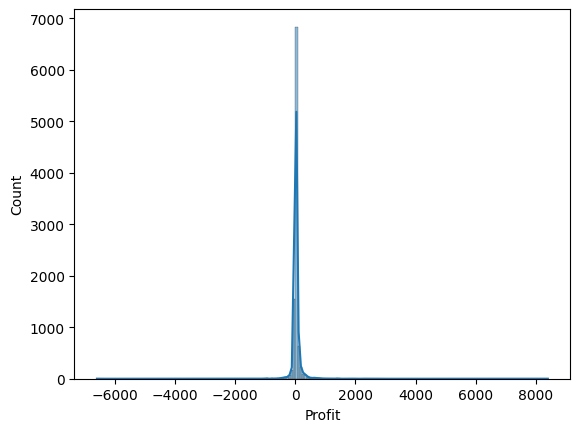

In [26]:
sns.histplot(df["Profit"], kde=True)

In [27]:
df["Profit"].skew()

np.float64(7.561035996041442)

<Axes: xlabel='Profit'>

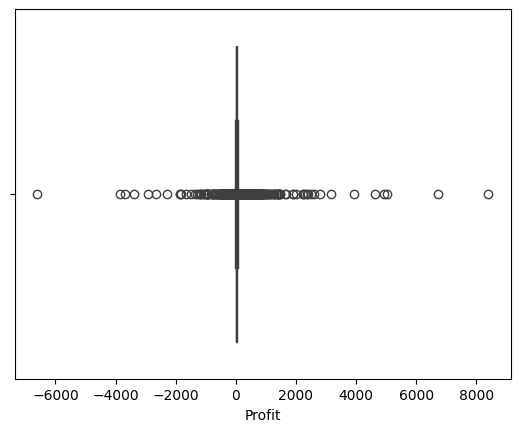

In [28]:
sns.boxplot(x=df["Profit"])

In [29]:
df["Profit_Pct"].mean()

np.float64(12.033025825827846)

In [30]:
(df["Profit"]<0).mean() * 100

np.float64(18.713099169418594)

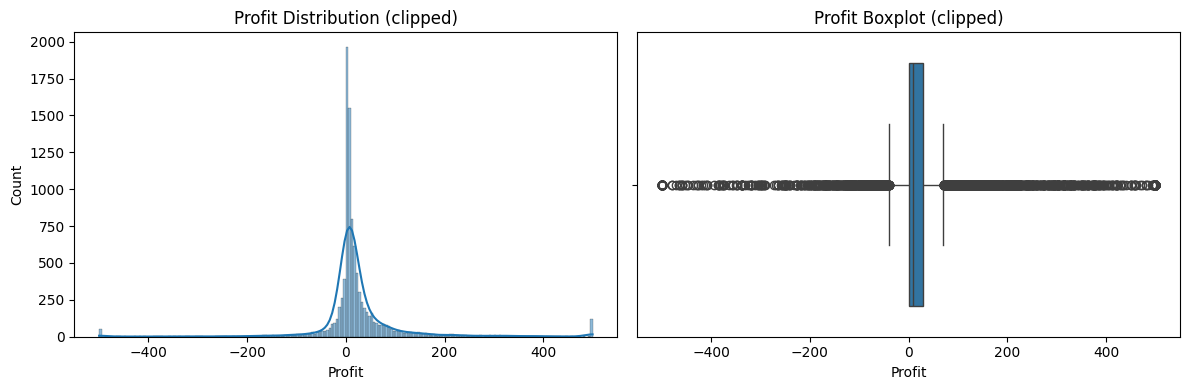

In [31]:
"""fig, axes = plt.subplots(1,2, figsize = (12,8))

sns.histplot(df["Profit"], kde=True, ax = axes[0], line_kws={"color" : "Red"})
axes[0].set_title("Profit Distribution")

sns.boxplot(x = df["Profit"], ax = axes[1])
axes[1].set_title("Profit Boxplot")

plt.tight_layout()
plt.show()"""


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

clipped = df["Profit"].clip(-500, 500)

sns.histplot(clipped, kde=True, ax=axes[0], line_kws={"color": "red"})
axes[0].set_title("Profit Distribution (clipped)")

sns.boxplot(x=clipped, ax=axes[1])
axes[1].set_title("Profit Boxplot (clipped)")

plt.tight_layout()
plt.show()

### Observation
- No missing values
- Mean is almost 3.5x median and skewness is 7.56. Few large profits are increasing the mean
- Outlier on both, positive and negative sides
- 18% of the sales are negative. Meaning 1 out of 5 sale are loss making
- Profit percentage is 12.03%

# Univariate Analysis

In [32]:
df.info()

<class 'pandas.DataFrame'>
Index: 9993 entries, 0 to 9993
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       9993 non-null   str    
 1   Order Date     9993 non-null   str    
 2   Ship Date      9993 non-null   str    
 3   Ship Mode      9993 non-null   str    
 4   Customer Name  9993 non-null   str    
 5   Segment        9993 non-null   str    
 6   City           9993 non-null   str    
 7   State          9993 non-null   str    
 8   Postal Code    9993 non-null   int64  
 9   Region         9993 non-null   str    
 10  Product ID     9993 non-null   str    
 11  Category       9993 non-null   str    
 12  Sub-Category   9993 non-null   str    
 13  Product Name   9993 non-null   str    
 14  Sales          9993 non-null   float64
 15  Quantity       9993 non-null   int64  
 16  Discount       9993 non-null   float64
 17  Profit         9993 non-null   float64
 18  Profit_Pct     9993 non-

## Numeric Columns

### Sales

In [33]:
df["Sales"].describe()

count     9993.000000
mean       229.852846
std        623.276074
min          0.444000
25%         17.280000
50%         54.480000
75%        209.940000
max      22638.480000
Name: Sales, dtype: float64

In [34]:
df["Sales"].skew()

np.float64(12.972141558363262)

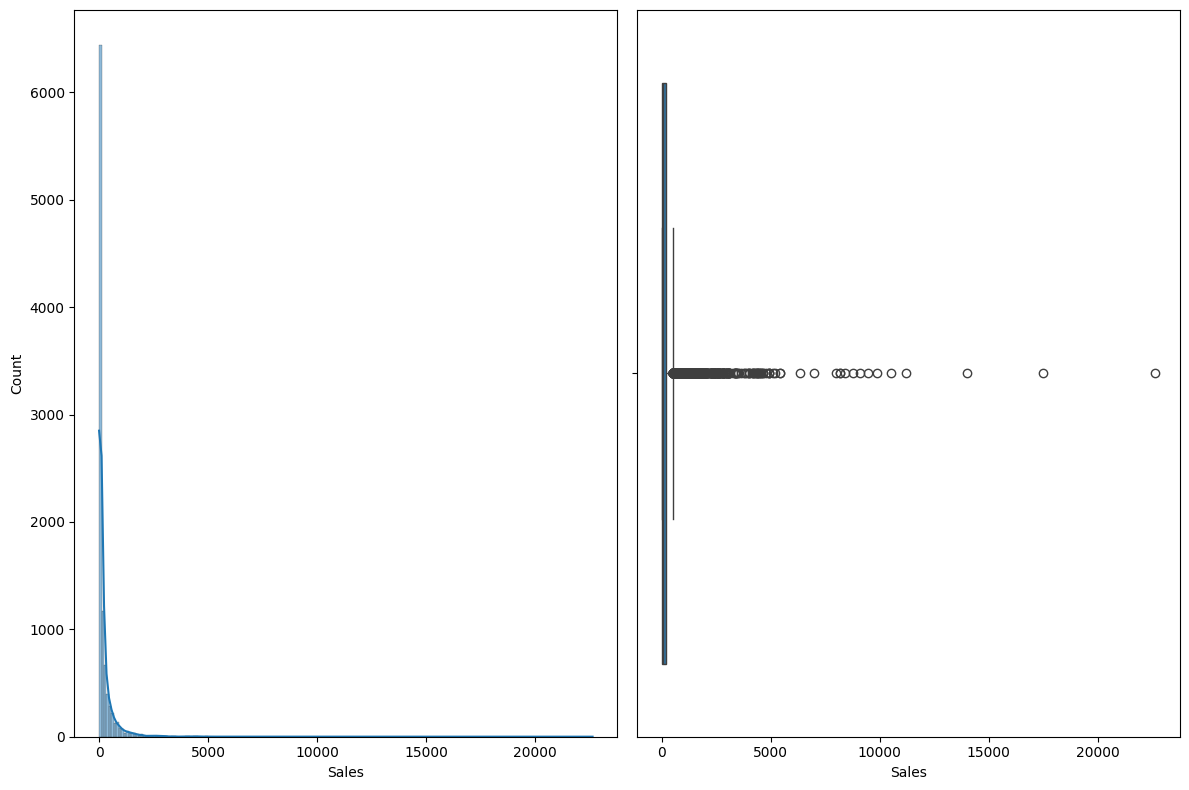

In [35]:
fig, axes = plt.subplots(1,2, figsize = (12,8))

sns.histplot(df["Sales"], kde = True, ax =  axes[0])
sns.boxplot(x = df["Sales"], ax = axes[1])

plt.tight_layout()
plt.show()


In [36]:
df["Sales"].corr(df["Profit"])

np.float64(0.4790666754131723)

### Observation
- Heavily right skewed, mean > median 
- Massive Outliers 
- Correlation of 0.47, useful feature

### Quantity

In [37]:
df["Quantity"].describe()

count    9993.000000
mean        3.789753
std         2.225149
min         1.000000
25%         2.000000
50%         3.000000
75%         5.000000
max        14.000000
Name: Quantity, dtype: float64

In [38]:
df["Quantity"].skew()

np.float64(1.2784155399852233)

In [39]:
df["Quantity"].corr(df["Profit"])

np.float64(0.06624144365358127)

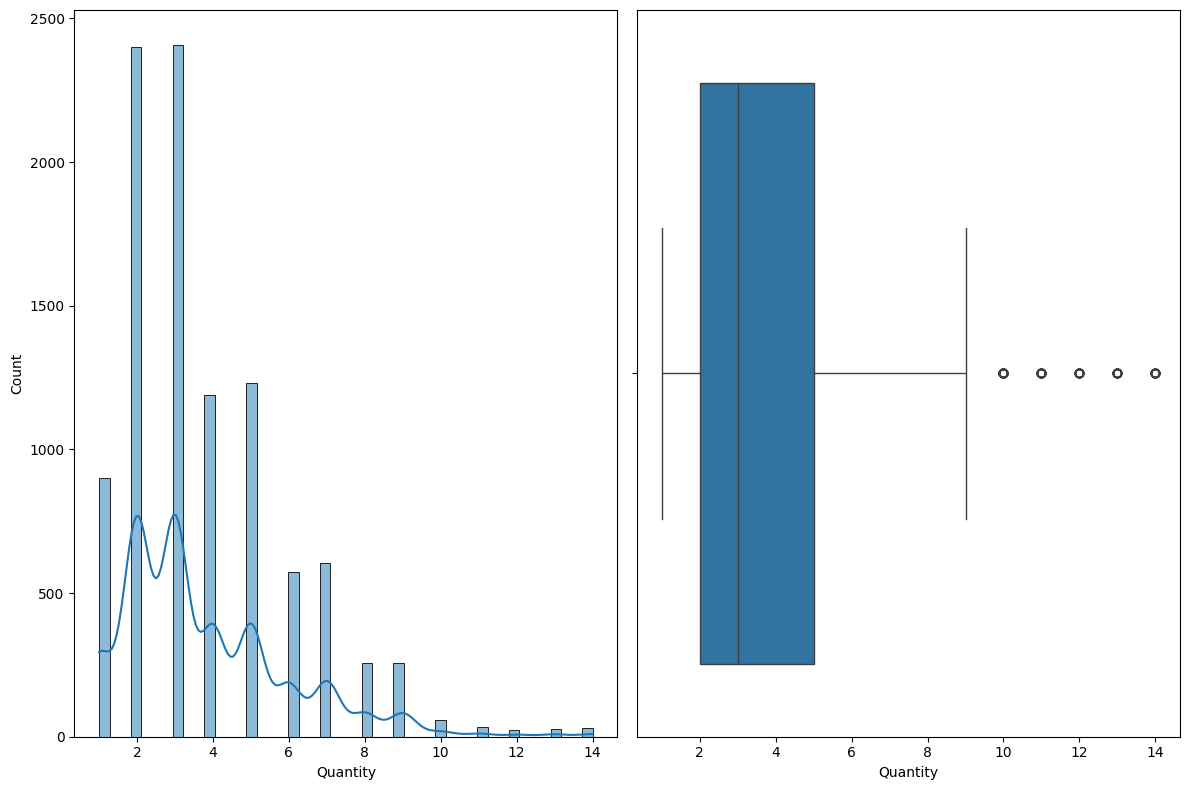

In [40]:
fig, axes = plt.subplots(1,2, figsize = (12,8))

sns.histplot(df["Quantity"], kde = True, ax = axes[0])
sns.boxplot(x= df["Quantity"], ax = axes[1])

plt.tight_layout()
plt.show()

In [41]:
def univariate_analysis():
    for col in df.select_dtypes(include="number").columns:
        print(f"\n --- {col} ---")
        print(df[col].describe())
        print(f"Missing Values: {df[col].isna().mean()*100}")
        print(f"Unique: {df[col].nunique()}")
        print(f"Skew: {df[col].skew():.2f}")
        print(f"Kurtosis: {df[col].kurtosis()}")

        fig, axes = plt.subplots(1,2, figsize = (12,4))

        sns.histplot(df[col], kde = True, ax=axes[0])
        axes[0].set_title({f"{col} Distribution"})

        sns.boxplot(x = df[col], ax = axes[1])
        axes[1].set_title(f"{col} Distribution")

        plt.tight_layout()
        plt.show()




 --- Postal Code ---
count     9993.000000
mean     55191.576403
std      32065.074478
min       1040.000000
25%      23223.000000
50%      56560.000000
75%      90008.000000
max      99301.000000
Name: Postal Code, dtype: float64
Missing Values: 0.0
Unique: 631
Skew: -0.13
Kurtosis: -1.49311185495478


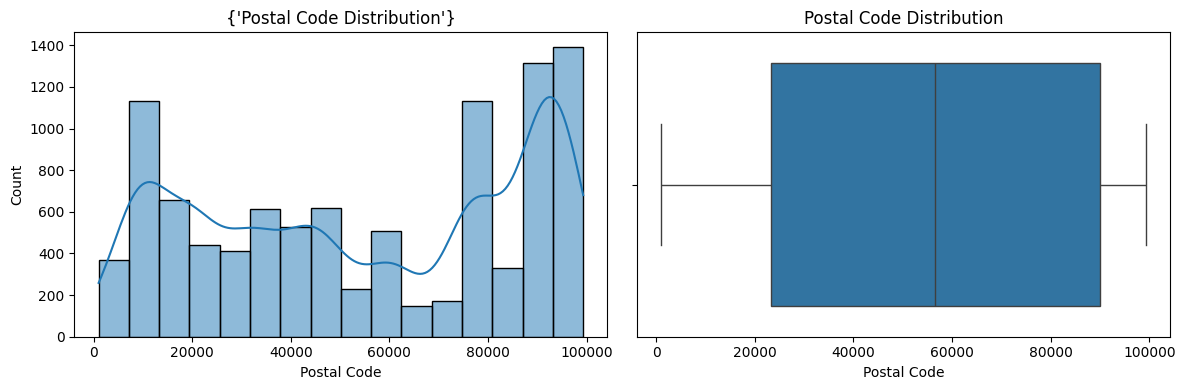


 --- Sales ---
count     9993.000000
mean       229.852846
std        623.276074
min          0.444000
25%         17.280000
50%         54.480000
75%        209.940000
max      22638.480000
Name: Sales, dtype: float64
Missing Values: 0.0
Unique: 5825
Skew: 12.97
Kurtosis: 305.2817697063499


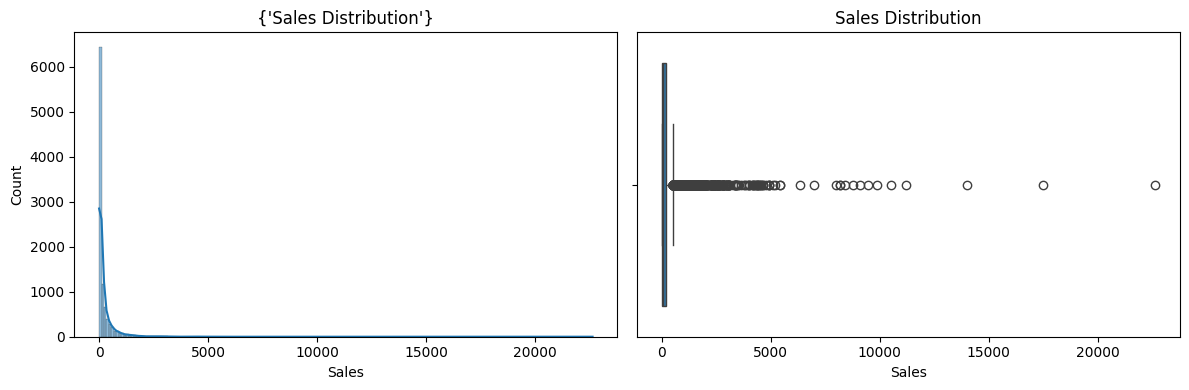


 --- Quantity ---
count    9993.000000
mean        3.789753
std         2.225149
min         1.000000
25%         2.000000
50%         3.000000
75%         5.000000
max        14.000000
Name: Quantity, dtype: float64
Missing Values: 0.0
Unique: 14
Skew: 1.28
Kurtosis: 1.9915827160047757


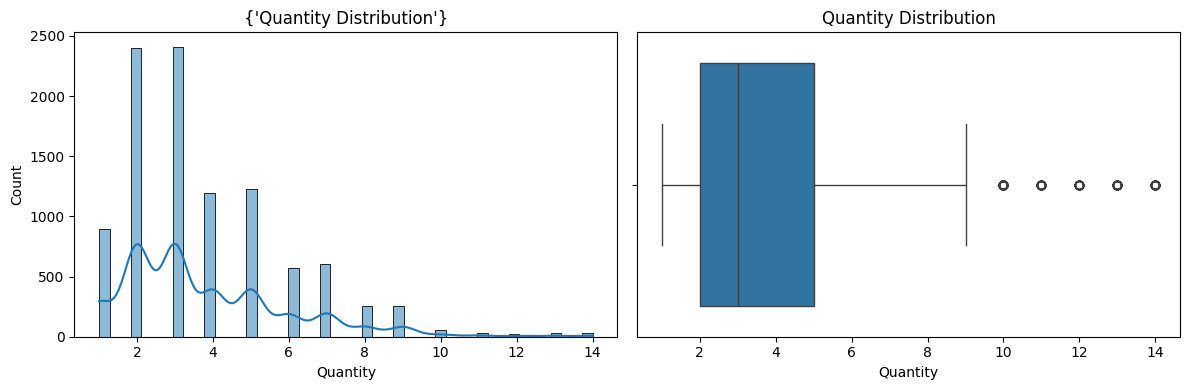


 --- Discount ---
count    9993.000000
mean        0.156188
std         0.206457
min         0.000000
25%         0.000000
50%         0.200000
75%         0.200000
max         0.800000
Name: Discount, dtype: float64
Missing Values: 0.0
Unique: 12
Skew: 1.68
Kurtosis: 2.409976524801519


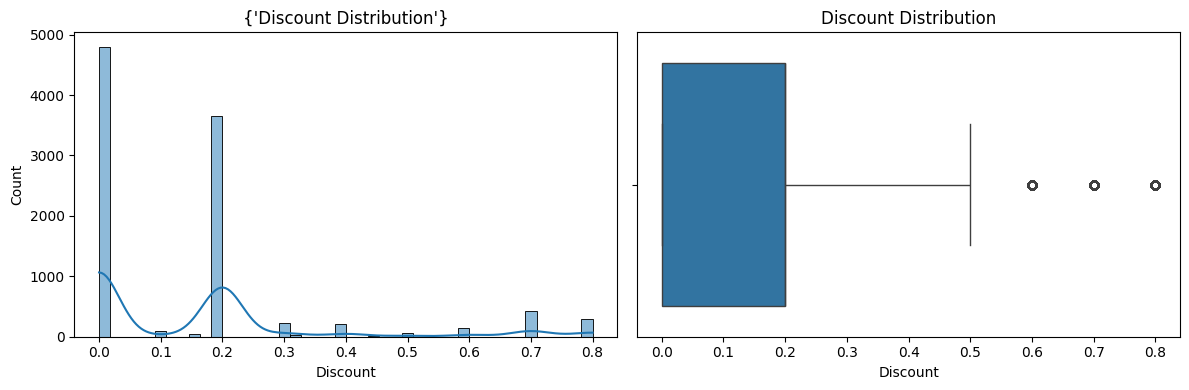


 --- Profit ---
count    9993.000000
mean       28.660971
std       234.271476
min     -6599.978000
25%         1.731000
50%         8.671000
75%        29.364000
max      8399.976000
Name: Profit, dtype: float64
Missing Values: 0.0
Unique: 7287
Skew: 7.56
Kurtosis: 397.1503847438924


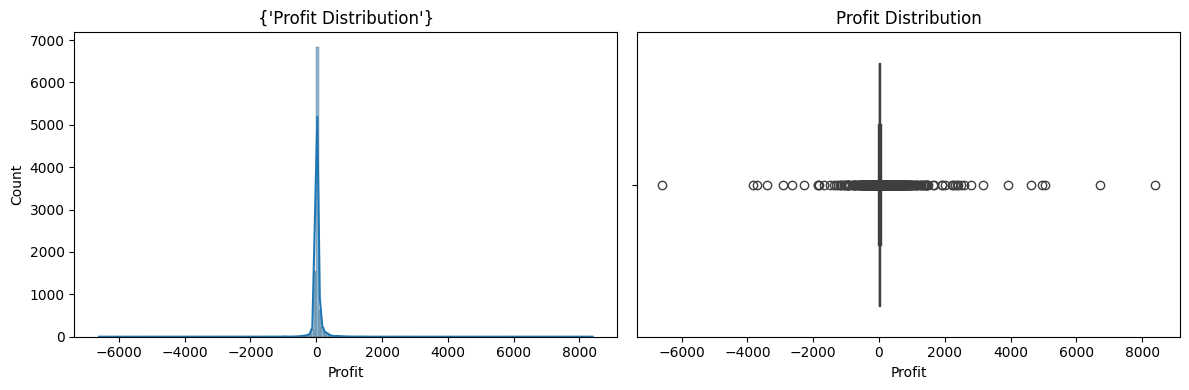


 --- Profit_Pct ---
count    9993.000000
mean       12.033026
std        46.677485
min      -275.000000
25%         7.500000
50%        27.000000
75%        36.250000
max        50.000000
Name: Profit_Pct, dtype: float64
Missing Values: 0.0
Unique: 525
Skew: -2.89
Kurtosis: 10.17275262282808


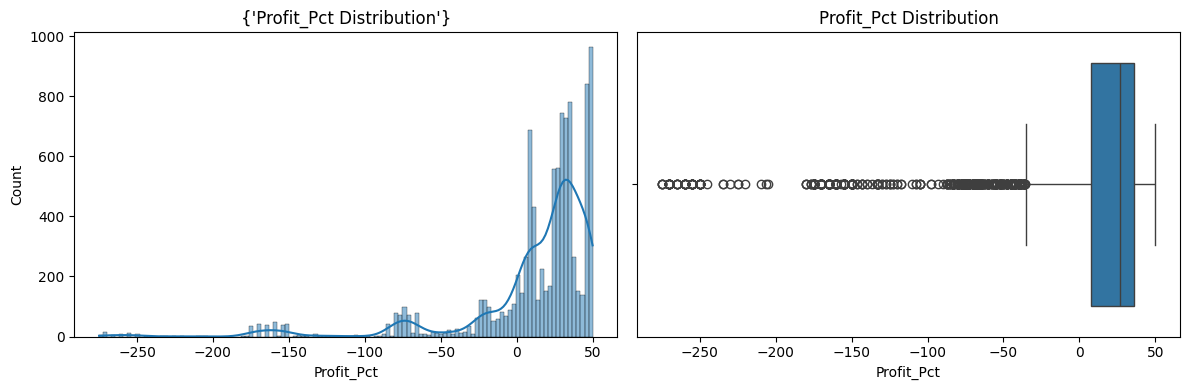

In [42]:
univariate_analysis()

### Observation
- All the numeric columns contain outlier
- Except for Profit_Pct, all are right skewed, showing that few large sales have inflated the mean

## Categorical Column

- 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer Name', 'Segment', 'City', 'State', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name'

In [49]:
def objects_unique ():
    for col in df.select_dtypes(include="str").columns:
        print(f" {col}: {df[col].nunique()}")
        
        

In [50]:
objects_unique()

 Order ID: 5009
 Order Date: 1237
 Ship Date: 1334
 Ship Mode: 4
 Customer Name: 793
 Segment: 3
 City: 531
 State: 49
 Region: 4
 Product ID: 1862
 Category: 3
 Sub-Category: 17
 Product Name: 1850


In [86]:
def objects_valuecount(threshold=15):

    cols = df.select_dtypes(include=["object", "string", "category"]).columns

    for col in cols:

        vc = df[col].value_counts()
        vc_pct = df[col].value_counts(normalize=True) * 100

        if df[col].nunique() <= threshold:

            print(f"\n--- {col} ---")
            print(pd.concat([vc, vc_pct.round(2)], axis=1, keys=["Count", "%"]))

            fig, ax = plt.subplots(figsize=(6, 4))
            bars = ax.bar(vc.index, vc.values)

            for i, v in enumerate(vc.values):
                pct = vc_pct.iloc[i]
                ax.text(i, v, f"{v}\n({pct:.1f}%)", ha="center", va="bottom")

            ax.set_title(col)
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()


--- Ship Mode ---
                Count      %
Ship Mode                   
Standard Class   5967  59.71
Second Class     1945  19.46
First Class      1538  15.39
Same Day          543   5.43


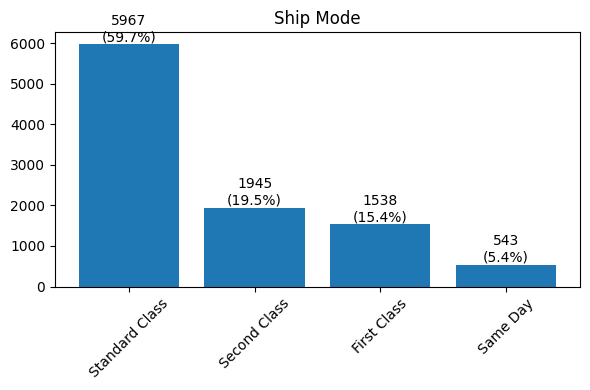


--- Segment ---
             Count      %
Segment                  
Consumer      5191  51.95
Corporate     3020  30.22
Home Office   1782  17.83


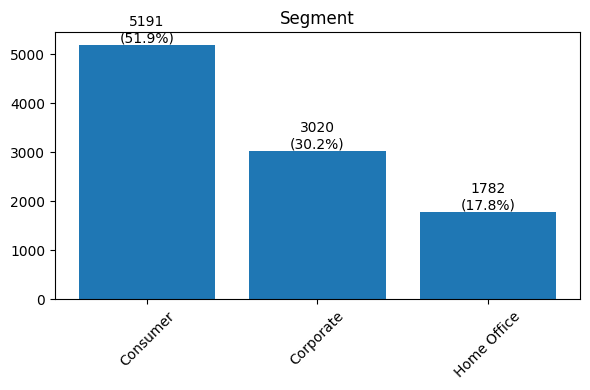


--- Region ---
         Count      %
Region               
West      3203  32.05
East      2847  28.49
Central   2323  23.25
South     1620  16.21


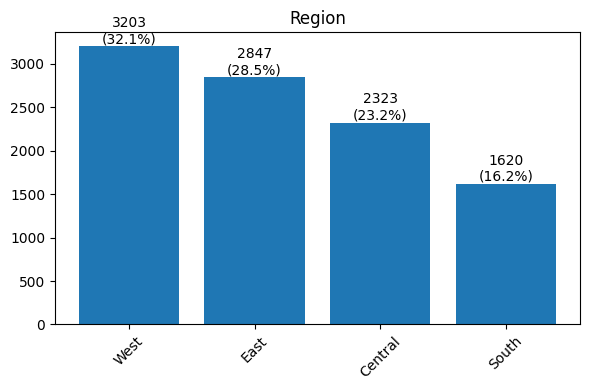


--- Category ---
                 Count      %
Category                     
Office Supplies   6026  60.30
Furniture         2120  21.21
Technology        1847  18.48


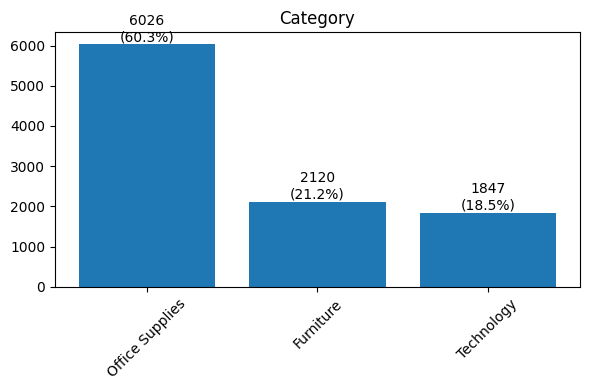

In [87]:
objects_valuecount()

In [79]:
df["Product Name"].value_counts(normalize=True)*100

Product Name
Staple envelope                                           0.480336
Easy-staple paper                                         0.460322
Staples                                                   0.460322
Avery Non-Stick Binders                                   0.200140
Staples in misc. colors                                   0.190133
                                                            ...   
RCA ViSYS 25425RE1 Corded phone                           0.010007
Cisco 8961 IP Phone Charcoal                              0.010007
Eureka Hand Vacuum, Bagless                               0.010007
LG G2                                                     0.010007
Eldon Jumbo ProFile Portable File Boxes Graphite/Black    0.010007
Name: proportion, Length: 1850, dtype: float64

In [80]:
df["Sub-Category"].value_counts(normalize=True)*100

Sub-Category
Binders        15.240668
Paper          13.709597
Furnishings     9.576704
Phones          8.896227
Storage         8.465926
Art             7.965576
Accessories     7.755429
Chairs          6.164315
Appliances      4.663264
Labels          3.642550
Tables          3.192235
Envelopes       2.541779
Bookcases       2.281597
Fasteners       2.171520
Supplies        1.901331
Machines        1.150806
Copiers         0.680476
Name: proportion, dtype: float64

In [83]:
df["Customer Name"].value_counts()

Customer Name
William Brown        37
Matt Abelman         34
John Lee             34
Paul Prost           34
Jonathan Doherty     32
                     ..
Jocasta Rupert        1
Anthony O'Donnell     1
Lela Donovan          1
Carl Jackson          1
Ricardo Emerson       1
Name: count, Length: 793, dtype: int64

In [84]:
df["City"].value_counts(normalize=True)*100

City
New York City        9.156409
Los Angeles          7.475233
Philadelphia         5.373762
San Francisco        5.103573
Seattle              4.282998
                       ...   
Aberdeen             0.010007
Hagerstown           0.010007
Arlington Heights    0.010007
San Luis Obispo      0.010007
Springdale           0.010007
Name: proportion, Length: 531, dtype: float64

In [89]:
df["State"].value_counts(normalize=True)*100

State
California              20.024017
New York                11.287902
Texas                    9.856900
Pennsylvania             5.874112
Washington               5.063544
Illinois                 4.923446
Ohio                     4.683278
Florida                  3.832683
Michigan                 2.551786
North Carolina           2.491744
Arizona                  2.241569
Virginia                 2.241569
Georgia                  1.841289
Tennessee                1.831282
Colorado                 1.821275
Indiana                  1.491044
Kentucky                 1.390974
Massachusetts            1.350946
New Jersey               1.300911
Oregon                   1.240869
Wisconsin                1.100771
Maryland                 1.050736
Delaware                 0.960672
Minnesota                0.890623
Connecticut              0.820574
Missouri                 0.660462
Oklahoma                 0.660462
Alabama                  0.610427
Arkansas                 0.600420
Rhode Is

In [90]:
def categorical_signal_strength(df, target):

    scores = []

    cat_cols = df.select_dtypes(include=["object", "string", "category"]).columns

    for col in cat_cols:

        # skip high-cardinality ID-like columns
        if df[col].nunique() > 50:
            continue

        group_means = df.groupby(col)[target].mean()

        score = group_means.std()   # <-- signal strength

        scores.append((col, score))

    return sorted(scores, key=lambda x: x[1], reverse=True)

In [91]:
ranked_features = categorical_signal_strength(df, "Profit")

for f, s in ranked_features:
    print(f"{f}: {s:.4f}")

Sub-Category: 195.9505
State: 51.2028
Category: 37.5377
Region: 7.5531
Segment: 4.0195
Ship Mode: 1.7814
